In [ ]:
!pip install -q kaggle scikit-learn tensorflow tqdm

import os, shutil

# Upload kaggle.json only if not already present
if not os.path.exists("/content/kaggle.json"):
    from google.colab import files
    files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)

if os.path.exists("/content/kaggle.json"):
    shutil.move("/content/kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d grassknoted/asl-alphabet

import zipfile

if not os.path.exists("asl_dataset"):
    with zipfile.ZipFile("asl-alphabet.zip", 'r') as zip_ref:
        zip_ref.extractall("asl_dataset")

print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:12<00:00, 90.9MB/s]

Dataset ready!


In [ ]:
from pathlib import Path

def find_dataset_root(base):
    base = Path(base)
    for d in base.rglob("*"):
        if d.is_dir():
            subs = [x.name for x in d.iterdir() if x.is_dir()]
            if "A" in subs and "B" in subs:
                return str(d)
    raise Exception("Dataset structure not found!")

dataset_root = find_dataset_root("/content/asl_dataset")
print("Dataset root:", dataset_root)
print("Sample classes:", os.listdir(dataset_root)[:5])

Dataset root: /content/asl_dataset/asl_alphabet_train/asl_alphabet_train
Sample classes: ['U', 'W', 'I', 'L', 'A']


In [ ]:
import numpy as np
import random
import time
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import IncrementalPCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

CONFIG = {
    "image_size": (64, 64),
    "sample_per_class": 500,  # SAFE for Colab
    "pca_components_list": [50, 75, 100],
    "test_size": 0.15,
    "random_seed": 42
}

random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

VALID_EXT = {".jpg", ".png", ".jpeg"}

In [ ]:
def load_data(root, sample_per_class):
    root = Path(root)
    classes = sorted([d for d in root.iterdir() if d.is_dir()])

    paths, labels = [], []

    for i, cls in enumerate(classes):
        imgs = [p for p in cls.iterdir() if p.suffix.lower() in VALID_EXT]
        imgs = sorted(imgs)

        if len(imgs) > sample_per_class:
            imgs = random.sample(imgs, sample_per_class)

        paths.extend(imgs)
        labels.extend([i]*len(imgs))

    return np.array(paths), np.array(labels), [c.name for c in classes]

paths, labels, class_names = load_data(dataset_root, CONFIG["sample_per_class"])
print("Total samples:", len(paths))

Total samples: 14500


In [ ]:
def process_image(p):
    img = Image.open(p).convert("L")
    img = img.resize(CONFIG["image_size"])
    arr = np.array(img, dtype=np.float32) / 255.0
    return arr.flatten()

X = np.array([process_image(p) for p in tqdm(paths)])
y = labels

print("Feature shape:", X.shape)

100%|██████████| 14500/14500 [00:15<00:00, 960.63it/s] 


Feature shape: (14500, 4096)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["test_size"],
    stratify=y,
    random_state=CONFIG["random_seed"]
)

# Keep RAW copy for CNN
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



Training RAW MLP...


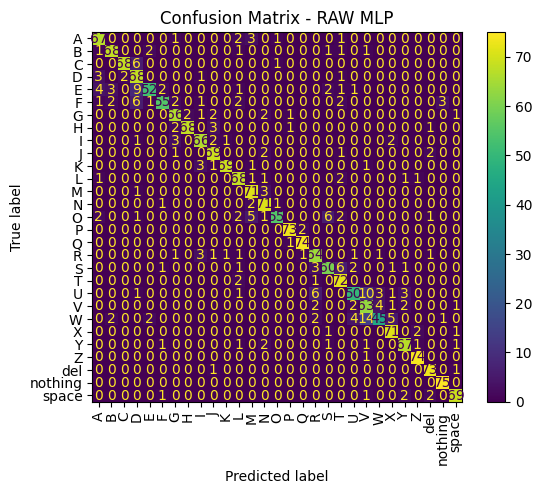

              precision    recall  f1-score   support

           A       0.85      0.89      0.87        75
           B       0.91      0.91      0.91        75
           C       0.97      0.91      0.94        75
           D       0.73      0.91      0.81        75
           E       0.91      0.69      0.79        75
           F       0.90      0.73      0.81        75
           G       0.87      0.88      0.87        75
           H       0.97      0.91      0.94        75
           I       0.88      0.88      0.88        75
           J       0.87      0.92      0.90        75
           K       0.97      0.92      0.95        75
           L       0.83      0.91      0.87        75
           M       0.86      0.95      0.90        75
           N       0.87      0.95      0.90        75
           O       0.95      0.73      0.83        75
           P       0.96      0.97      0.97        75
           Q       0.96      0.99      0.97        75
           R       0.82    

In [ ]:
print("\nTraining RAW MLP...")
start = time.time()

mlp_raw = MLPClassifier(hidden_layer_sizes=(256,128),
                        max_iter=50,
                        early_stopping=True,
                        verbose=False)

mlp_raw.fit(X_train, y_train)

raw_time = time.time() - start
#raw_acc = accuracy_score(y_test, mlp_raw.predict(X_test))
raw_pred = mlp_raw.predict(X_test)
raw_acc = accuracy_score(y_test, raw_pred)

cm = confusion_matrix(y_test, raw_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix - RAW MLP")
plt.show()

print(classification_report(y_test, raw_pred, target_names=class_names))
print(f"RAW → Acc: {raw_acc:.4f}, Time: {raw_time:.2f}s")


PCA (50)


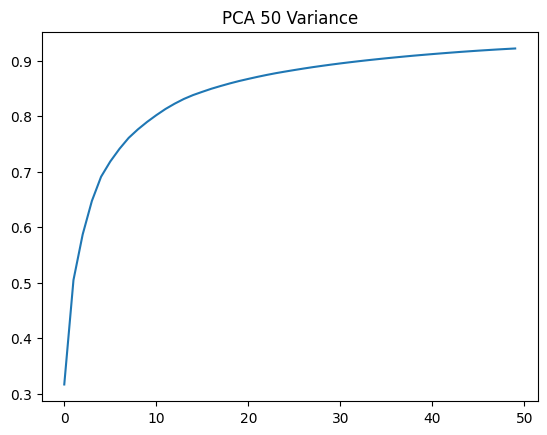

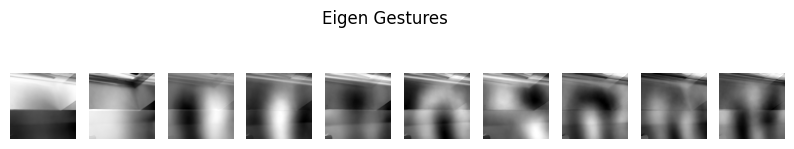

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


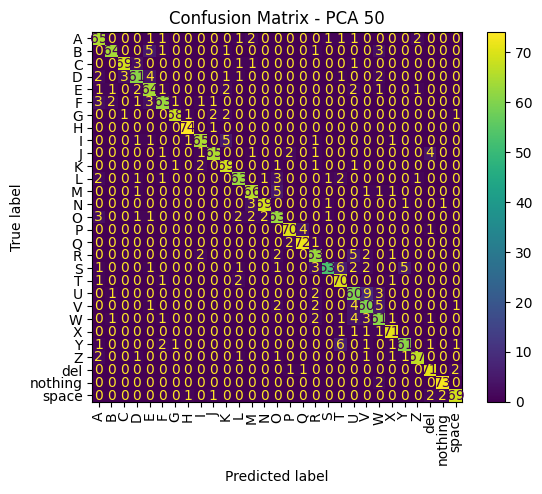

              precision    recall  f1-score   support

           A       0.80      0.87      0.83        75
           B       0.93      0.85      0.89        75
           C       0.95      0.92      0.93        75
           D       0.85      0.81      0.83        75
           E       0.79      0.85      0.82        75
           F       0.88      0.84      0.86        75
           G       0.96      0.91      0.93        75
           H       0.96      0.99      0.97        75
           I       0.92      0.87      0.89        75
           J       0.93      0.87      0.90        75
           K       0.86      0.92      0.89        75
           L       0.88      0.84      0.86        75
           M       0.88      0.88      0.88        75
           N       0.96      0.92      0.94        75
           O       0.81      0.84      0.82        75
           P       0.93      0.93      0.93        75
           Q       0.94      0.96      0.95        75
           R       0.82    

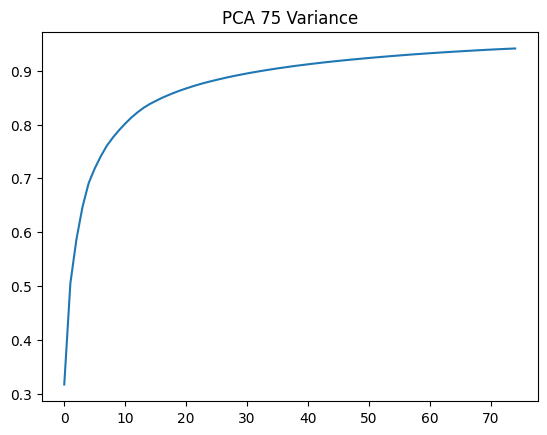

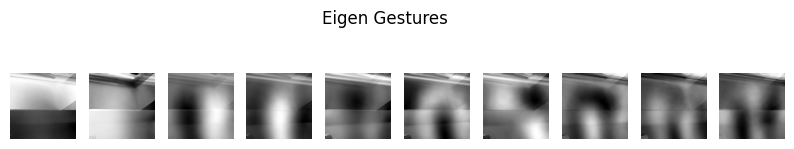

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


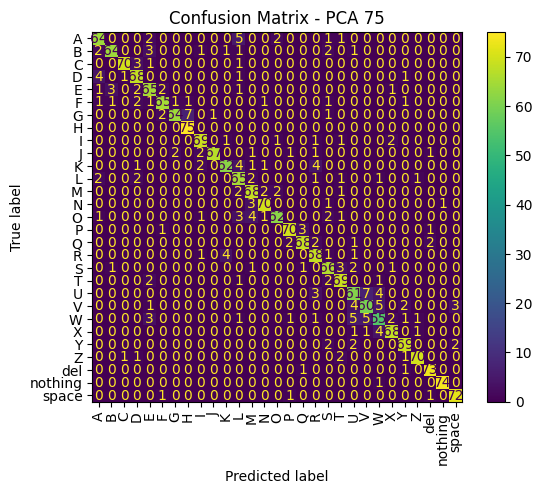

              precision    recall  f1-score   support

           A       0.85      0.85      0.85        75
           B       0.93      0.85      0.89        75
           C       0.97      0.93      0.95        75
           D       0.86      0.91      0.88        75
           E       0.83      0.87      0.85        75
           F       0.92      0.87      0.89        75
           G       0.96      0.85      0.90        75
           H       0.90      1.00      0.95        75
           I       0.91      0.92      0.91        75
           J       0.99      0.89      0.94        75
           K       0.91      0.83      0.87        75
           L       0.76      0.87      0.81        75
           M       0.85      0.91      0.88        75
           N       0.93      0.93      0.93        75
           O       0.93      0.83      0.87        75
           P       0.93      0.93      0.93        75
           Q       0.93      0.91      0.92        75
           R       0.84    

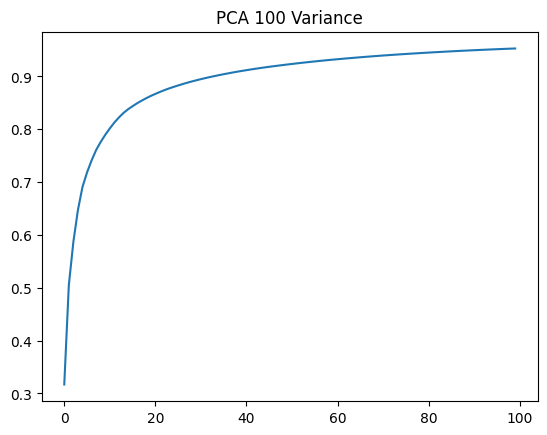

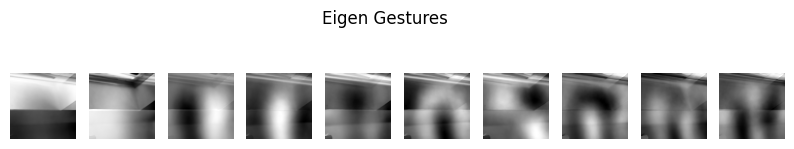

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


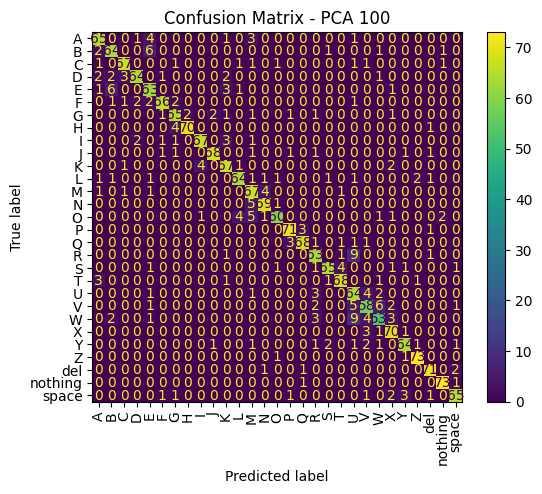

              precision    recall  f1-score   support

           A       0.86      0.87      0.86        75
           B       0.84      0.85      0.85        75
           C       0.92      0.89      0.91        75
           D       0.93      0.85      0.89        75
           E       0.78      0.84      0.81        75
           F       0.93      0.88      0.90        75
           G       0.87      0.87      0.87        75
           H       0.97      0.93      0.95        75
           I       0.93      0.89      0.91        75
           J       0.96      0.91      0.93        75
           K       0.85      0.89      0.87        75
           L       0.90      0.85      0.88        75
           M       0.77      0.89      0.83        75
           N       0.91      0.92      0.91        75
           O       0.92      0.80      0.86        75
           P       0.92      0.95      0.93        75
           Q       0.93      0.91      0.92        75
           R       0.83    

In [ ]:
results = []

for n in CONFIG["pca_components_list"]:
    print(f"\nPCA ({n})")

    pca = IncrementalPCA(n_components=n, batch_size=500)

    start_pca = time.time()
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    pca_time = time.time() - start_pca

    explained = np.sum(pca.explained_variance_ratio_)

    # Explained variance plot
    plt.figure()
    plt.plot(np.cumsum(pca.explained_variance_ratio_))
    plt.title(f"PCA {n} Variance")
    plt.show()

    # Eigen gestures
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(pca.components_[i].reshape(CONFIG["image_size"]), cmap="gray")
        plt.axis("off")
    plt.suptitle("Eigen Gestures")
    plt.show()

    # MLP
    start = time.time()

    mlp = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=50,
        early_stopping=True,
        verbose=False
    )

    mlp.fit(X_train_pca, y_train)

    train_time = time.time() - start
    total_time = train_time + pca_time

    pca_pred = mlp.predict(X_test_pca)
    acc = accuracy_score(y_test, pca_pred)

    cm = confusion_matrix(y_test, pca_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    disp.plot(xticks_rotation=90)
    plt.title(f"Confusion Matrix - PCA {n}")
    plt.show()

    print(classification_report(y_test, pca_pred, target_names=class_names))

    print(f"Acc: {acc:.4f}, Time: {total_time:.2f}s")

    results.append((f"PCA-{n}", acc, total_time))


Training CNN...
Epoch 1/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 98s 533ms/step - accuracy: 0.2363 - loss: 2.7117 - val_accuracy: 0.4039 - val_loss: 1.9565
Epoch 2/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 81s 463ms/step - accuracy: 0.5677 - loss: 1.4658 - val_accuracy: 0.6107 - val_loss: 1.2376
Epoch 3/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 83s 475ms/step - accuracy: 0.7309 - loss: 0.8778 - val_accuracy: 0.7380 - val_loss: 0.8370
Epoch 4/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 80s 459ms/step - accuracy: 0.8252 - loss: 0.5708 - val_accuracy: 0.8273 - val_loss: 0.6259
Epoch 5/5
174/174 ━━━━━━━━━━━━━━━━━━━━ 54s 307ms/step - accuracy: 0.8853 - loss: 0.3842 - val_accuracy: 0.8443 - val_loss: 0.5600
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step


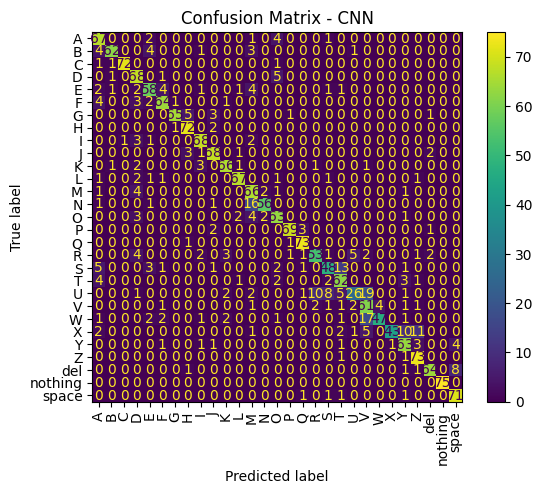

              precision    recall  f1-score   support

           A       0.72      0.89      0.80        75
           B       0.94      0.83      0.88        75
           C       0.99      0.96      0.97        75
           D       0.74      0.91      0.81        75
           E       0.78      0.77      0.78        75
           F       0.85      0.85      0.85        75
           G       0.97      0.87      0.92        75
           H       0.88      0.96      0.92        75
           I       0.87      0.91      0.89        75
           J       0.87      0.91      0.89        75
           K       0.89      0.88      0.89        75
           L       0.92      0.89      0.91        75
           M       0.66      0.88      0.75        75
           N       0.93      0.75      0.83        75
           O       0.79      0.84      0.81        75
           P       0.96      0.92      0.94        75
           Q       0.91      0.97      0.94        75
           R       0.80    

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

X_train_cnn = X_train_raw.reshape(-1,64,64,1)
X_test_cnn = X_test_raw.reshape(-1,64,64,1)

print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(64,64,1)),
    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(len(class_names),activation='softmax')
])

cnn.compile(optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

start = time.time()

cnn.fit(X_train_cnn, y_train,
        epochs=5,
        batch_size=64,
        validation_split=0.1,
        verbose=1)

cnn_time = time.time() - start
cnn_probs = cnn.predict(X_test_cnn)
cnn_pred = np.argmax(cnn_probs, axis=1)

cnn_acc = accuracy_score(y_test, cnn_pred)

cm = confusion_matrix(y_test, cnn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix - CNN")
plt.show()

print(classification_report(y_test, cnn_pred, target_names=class_names))

print(f"CNN → Acc: {cnn_acc:.4f}, Time: {cnn_time:.2f}s")


Training PCA + KNN...
PCA + KNN Accuracy: 0.8189
PCA + KNN Time: 28.69s


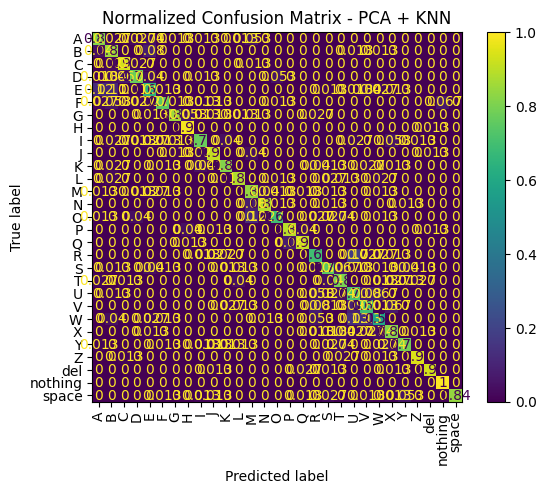

              precision    recall  f1-score   support

           A       0.75      0.81      0.78        75
           B       0.68      0.85      0.76        75
           C       0.91      0.93      0.92        75
           D       0.83      0.77      0.80        75
           E       0.66      0.64      0.65        75
           F       0.88      0.75      0.81        75
           G       0.94      0.85      0.90        75
           H       0.90      0.99      0.94        75
           I       0.83      0.77      0.80        75
           J       0.88      0.91      0.89        75
           K       0.86      0.81      0.84        75
           L       0.89      0.88      0.89        75
           M       0.72      0.84      0.78        75
           N       0.92      0.88      0.90        75
           O       0.87      0.69      0.77        75
           P       0.92      0.89      0.91        75
           Q       0.91      0.91      0.91        75
           R       0.69    

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import time
import matplotlib.pyplot as plt

print("\nTraining PCA + KNN...")

knn_pca_components = 100

pca_knn = IncrementalPCA(n_components=knn_pca_components, batch_size=500)

start_pca = time.time()
X_train_knn_pca = pca_knn.fit_transform(X_train)
X_test_knn_pca = pca_knn.transform(X_test)
pca_knn_time = time.time() - start_pca

knn = KNeighborsClassifier(n_neighbors=5)

start = time.time()
knn.fit(X_train_knn_pca, y_train)
knn_pred = knn.predict(X_test_knn_pca)
knn_time = time.time() - start

knn_total_time = pca_knn_time + knn_time
knn_acc = accuracy_score(y_test, knn_pred)

print(f"PCA + KNN Accuracy: {knn_acc:.4f}")
print(f"PCA + KNN Time: {knn_total_time:.2f}s")


cm_knn = confusion_matrix(y_test, knn_pred, normalize="true")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=class_names
)

disp.plot(xticks_rotation=90)
plt.title("Normalized Confusion Matrix - PCA + KNN")
plt.show()

print(classification_report(y_test, knn_pred, target_names=class_names))

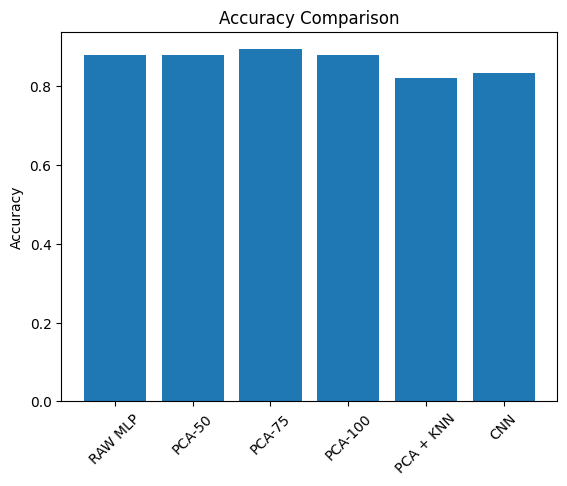

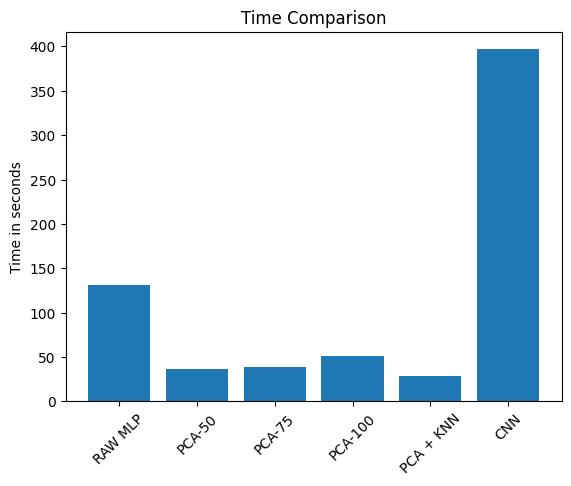


FINAL RESULTS:
RAW MLP → Acc: 0.8786, Time: 131.06s
PCA-50 → Acc: 0.8777, Time: 36.83s
PCA-75 → Acc: 0.8924, Time: 38.22s
PCA-100 → Acc: 0.8791, Time: 51.67s
PCA + KNN → Acc: 0.8189, Time: 28.69s
CNN → Acc: 0.8322, Time: 396.64s


In [ ]:
labels_plot = ["RAW MLP"] + [r[0] for r in results] + ["PCA + KNN", "CNN"]
accs = [raw_acc] + [r[1] for r in results] + [knn_acc, cnn_acc]
times = [raw_time] + [r[2] for r in results] + [knn_total_time, cnn_time]

plt.figure()
plt.bar(labels_plot, accs)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.bar(labels_plot, times)
plt.title("Time Comparison")
plt.ylabel("Time in seconds")
plt.xticks(rotation=45)
plt.show()

print("\nFINAL RESULTS:")
for l, a, t in zip(labels_plot, accs, times):
    print(f"{l} → Acc: {a:.4f}, Time: {t:.2f}s")